In [35]:
## Importo Librerie
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt

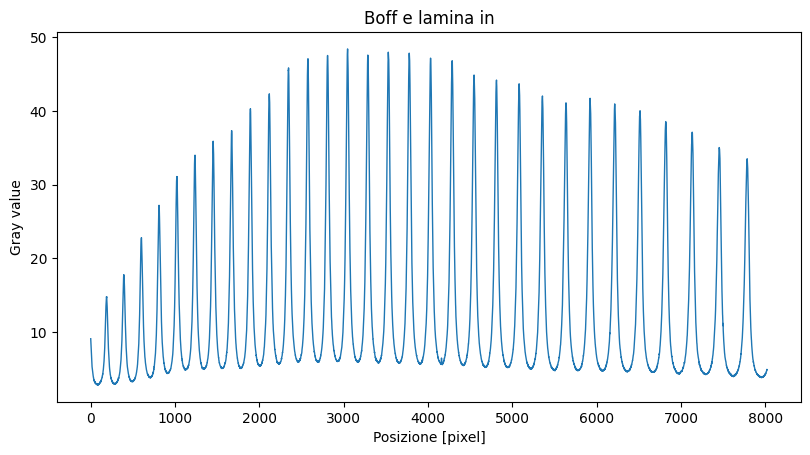

In [57]:
# Analisi spettro lamina inserita
dataLamNr = pd.read_csv('CSV/l_ho_inserita_tutta.csv') #Lamina in B = 0 non ruotato
x = dataLamNr['Distance_(pixels)']
y = dataLamNr['Gray_Value']
# Genero il canvas dei grafici
fig, ax = plt.subplots(figsize = (9.6,4.8))
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")
plt.title("Boff e lamina in")

plt.plot(x,y, lw = 1,label='Data')
plt.show()

[ 0.14093245  0.19933786 14.72356412]


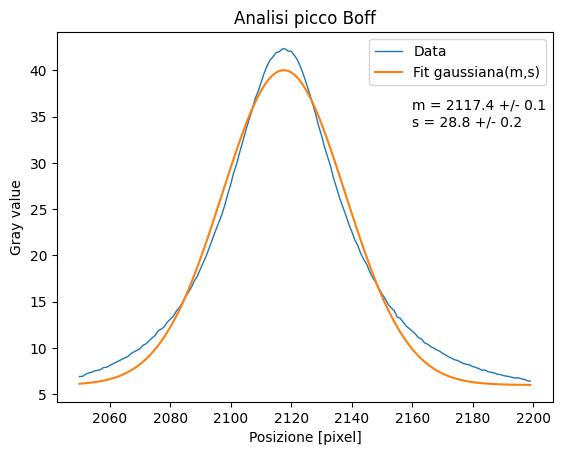

In [37]:
xfit = x[2050:2200]
yfit = y[2050:2200]

def picco(x,m,s,a):
    return a*1/(2*np.pi)**0.5 * 1/s * np.exp(-((x-m)/s)**2) + 6

par, spar = curve_fit(picco, xfit, yfit, p0 = (2125, 60, 50), absolute_sigma = True)

fig, ax = plt.subplots()
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")

err = np.sqrt(np.diag(spar))
stringa = "m = " + str(round(par[0]-0.1, 1)) + " +/- " + str(round(err[0],1)) + " \ns = " + str(round(par[1], 1)) + " +/- " + str(round(err[1],1))

print(np.sqrt(np.diag(spar)))

ax.text(2160,34, stringa)

plt.plot(xfit,yfit, lw = 1,label='Data')
plt.plot(xfit, picco(xfit, *par), label='Fit gaussiana(m,s)')

plt.legend()

plt.title("Analisi picco Boff")

plt.show()

In [38]:
threshold = 12
picchi = [[],[]]
mezzipicchi = [[],[]]

temp = [[],[]]

for i in x:
    if y[i] > threshold:
        temp[1].append(y[i])
        temp[0].append(i)
    if y[i] < threshold and len(temp[0]) != 0:
        picchi[1].append(np.max(temp[1]))
        for i in range(len(temp[0])):
            if temp[1][i] == np.max(temp[1]):
                picchi[0].append(temp[0][i])
                break
        first = True
        for i in range(len(temp[0])):
            if temp[1][i] > np.max(temp[1])/2 and first:
                mezzipicchi[0].append(temp[0][i])
                mezzipicchi[1].append(temp[1][i])
                first = False
            if temp[1][i] < np.max(temp[1])/2 and not first:
                mezzipicchi[0].append(temp[0][i])
                mezzipicchi[1].append(temp[1][i])
                break
                
        temp = [[],[]]

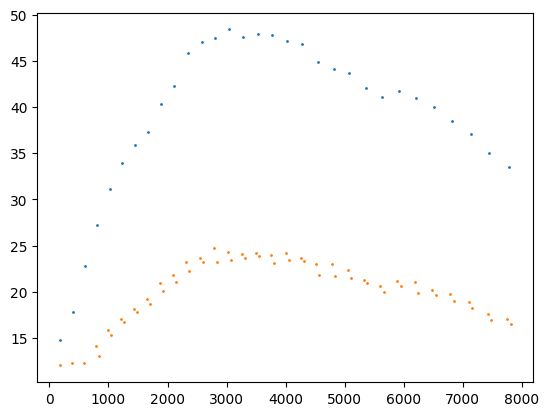

In [39]:
fig, ax = plt.subplots()

plt.scatter(*picchi, label='Data', s = 1)
plt.scatter(*mezzipicchi, label='Data', s = 1)

plt.show()

In [40]:
c = np.array(picchi[0][1:]) - np.array(picchi[0][:-1])
print(np.mean(c),np.std(c, ddof = 1))


253.26666666666668 36.872504786024535


In [41]:
for i in range(8,len(picchi[0]) - 8):
    print(picchi[0][i], end=';')
    print(c[i-1],end=';')
    print(c[i], end=';')
    print((c[i-1]+c[i])/2)

1894;223;223;223.0
2117;223;229;226.0
2346;229;230;229.5
2576;230;233;231.5
2809;233;237;235.0
3046;237;240;238.5
3286;240;243;241.5
3529;243;248;245.5
3777;248;253;250.5
4030;253;256;254.5
4286;256;259;257.5
4545;259;267;263.0
4812;267;268;267.5
5080;268;277;272.5
5357;277;279;278.0


In [42]:
for i in range(15,len(mezzipicchi[0]) - 16, 2):
    print(picchi[0][(i+1)//2])
    print(mezzipicchi[0][i+1]- mezzipicchi[0][i])

1894
48
2117
49
2346
49
2576
49
2809
50
3046
50
3286
50
3529
52
3777
51
4030
52
4286
53
4545
53
4812
54
5080
55


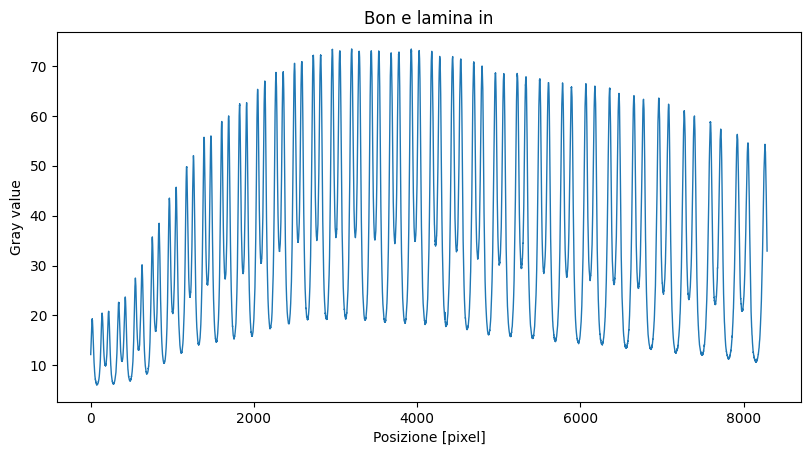

In [58]:
# Analisi spettro lamina inserita
dataLamBNr = pd.read_csv('CSV/Mhh_sei_magnetico.csv') #Lamina in B non ruotato
x = dataLamBNr['Distance_(pixels)']
y = dataLamBNr['Gray_Value']
# Genero il canvas dei grafici
fig, ax = plt.subplots(figsize = (9.6,4.8))
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")

plt.title("Bon e lamina in")

plt.plot(x,y, lw = 1,label='Data')
plt.show()

[ 0.10238088  0.159349   15.81309037]


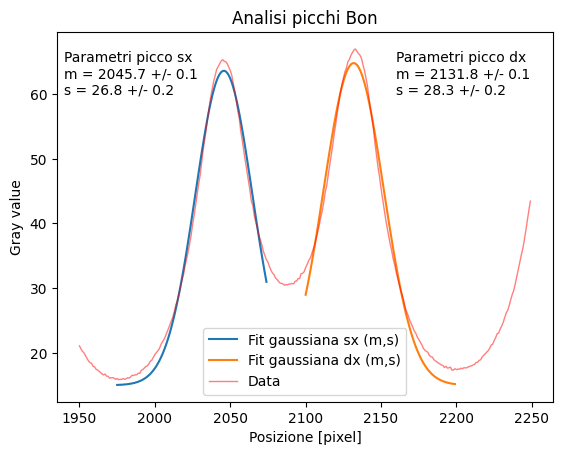

In [48]:
xfit = x[1950:2250]
yfit = y[1950:2250]

def picco(x,m,s,a):
    return a*1/(2*np.pi)**0.5 * 1/s * np.exp(-((x-m)/s)**2) + 15

fig, ax = plt.subplots()
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")

par, spar = curve_fit(picco, xfit[25:125], yfit[25:125], p0 = (2000, 30, 50), absolute_sigma = True)

err = np.sqrt(np.diag(spar))
stringa = "Parametri picco sx \nm = " + str(round(par[0]-0.1, 1)) + " +/- " + str(round(err[0],1)) + " \ns = " + str(round(par[1], 1)) + " +/- " + str(round(err[1],1))
plt.plot(xfit[25:125], picco(xfit[25:125], *par), label='Fit gaussiana sx (m,s)')
ax.text(1940,60, stringa)

print(np.sqrt(np.diag(spar)))

par, spar = curve_fit(picco, xfit[150:-50], yfit[150:-50], p0 = (2000, 30, 50), absolute_sigma = True)

err = np.sqrt(np.diag(spar))
stringa = "Parametri picco dx \nm = " + str(round(par[0]-0.1, 1)) + " +/- " + str(round(err[0],1)) + " \ns = " + str(round(par[1], 1)) + " +/- " + str(round(err[1],1))
plt.plot(xfit[150:-50], picco(xfit[150:-50], *par), label='Fit gaussiana dx (m,s)')
ax.text(2160,60, stringa)

plt.title("Analisi picchi Bon")

plt.plot(xfit,yfit, c='r', lw = 1,label='Data', alpha = 0.5)

plt.legend()

plt.show()

In [49]:
threshold = 40
picchi = [[],[]]

temp = [[],[]]

for i in x[2000:8100]:
    if y[i] > threshold:
        temp[1].append(y[i])
        temp[0].append(i)
    if y[i] < threshold and len(temp[0]) != 0:
        picchi[1].append(np.max(temp[1]))
        for i in range(len(temp[0])):
            if temp[1][i] == np.max(temp[1]):
                picchi[0].append(temp[0][i])
                break
                
        temp = [[],[]]

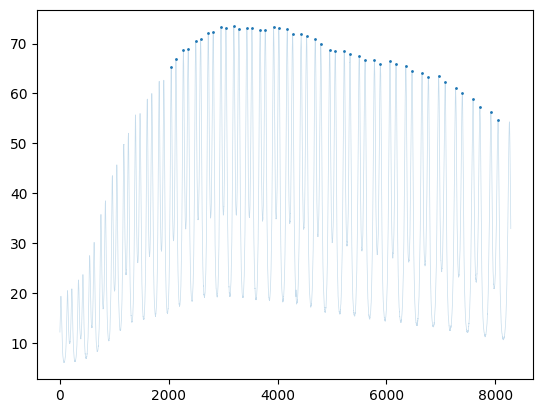

133.51111111111112 35.01663385399354


In [50]:
fig, ax = plt.subplots()

plt.scatter(*picchi, label='Data', s = 1)

plt.plot(x,y, lw = 0.5, alpha = 0.25)


plt.show()

c = np.array(picchi[0][1:]) - np.array(picchi[0][:-1])
print(np.mean(c),np.std(c, ddof = 1))


In [51]:
for i in range(2,len(picchi[0])-2, 2):
    print(picchi[0][i], end=' ')
    print(picchi[0][i+1], end=' ')

    print(picchi[0][i]-picchi[0][i-2],end=' ')
    print(picchi[0][i+1]-picchi[0][i-1],end=' ')

    print(picchi[0][i+2]-picchi[0][i], end=' ')
    print(picchi[0][i+3]-picchi[0][i+1], end=' ')
    
    print((picchi[0][i+2]-picchi[0][i-2])/2, end=' ')
    print((picchi[0][i+3]-picchi[0][i-1])/2)


2270 2359 225 226 228 226 226.5 226.0
2498 2585 228 226 230 233 229.0 229.5
2728 2818 230 233 234 234 232.0 233.5
2962 3052 234 234 235 236 234.5 235.0
3197 3288 235 236 240 241 237.5 238.5
3437 3529 240 241 244 248 242.0 244.5
3681 3777 244 248 247 247 245.5 247.5
3928 4024 247 247 251 252 249.0 249.5
4179 4276 251 252 256 258 253.5 255.0
4435 4534 256 258 258 260 257.0 259.0
4693 4794 258 260 266 267 262.0 263.5
4959 5061 266 267 266 272 266.0 269.5
5225 5333 266 272 277 277 271.5 274.5
5502 5610 277 277 279 281 278.0 279.0
5781 5891 279 281 286 286 282.5 283.5
6067 6177 286 286 293 295 289.5 290.5
6360 6472 293 295 295 301 294.0 298.0
6655 6773 295 301 307 307 301.0 304.0
6962 7080 307 307 311 317 309.0 312.0
7273 7397 311 317 319 322 315.0 319.5
7592 7719 319 322 330 334 324.5 328.0


In [54]:
for i in range(2,len(picchi[0])-2, 2):
    print((picchi[0][i+2]-picchi[0][i-2]+picchi[0][i+3]-picchi[0][i-1])/4)
print('')
for i in range(2,len(picchi[0])-2, 2):
    print(picchi[0][i+1]-picchi[0][i])


226.25
229.25
232.75
234.75
238.0
243.25
246.5
249.25
254.25
258.0
262.75
267.75
273.0
278.5
283.0
290.0
296.0
302.5
310.5
317.25
326.25

89
87
90
90
91
92
96
96
97
99
101
102
108
108
110
110
112
118
118
124
127


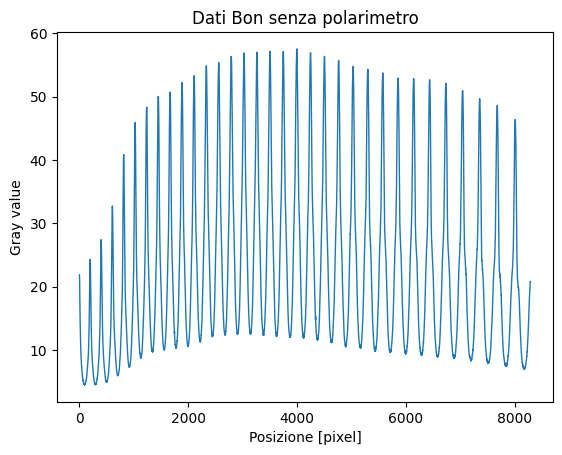

In [18]:
# Analisi spettro lamina inserita
dataLamBr = pd.read_csv('CSV/magneticoMaStorto.csv') #Lamina in B non ruotato
x = dataLamBr['Distance_(pixels)']
y = dataLamBr['Gray_Value']
# Genero il canvas dei grafici
fig, ax = plt.subplots()
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")

plt.title("Dati Bon senza polarimetro")

plt.plot(x,y, lw = 1,label='Data')
plt.show()

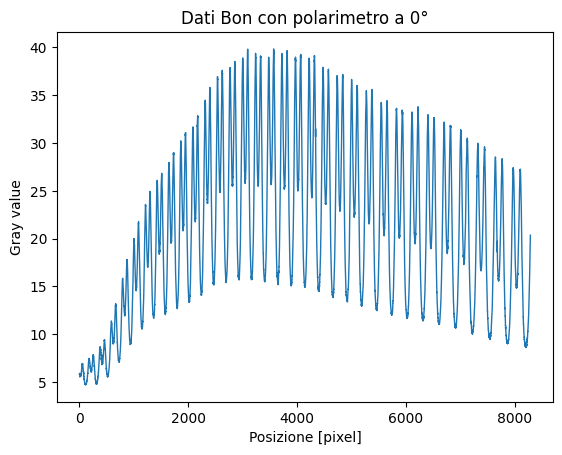

In [19]:
# Analisi spettro lamina inserita
dataLamBr0 = pd.read_csv('CSV/Marco_Polo_00.csv') #Lamina in B non ruotato
x1 = dataLamBr0['Distance_(pixels)']
y1 = dataLamBr0['Gray_Value']
# Genero il canvas dei grafici
fig, ax = plt.subplots()
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")

plt.title("Dati Bon con polarimetro a 0°")

plt.plot(x1,y1, lw = 1,label='Data')
plt.show()

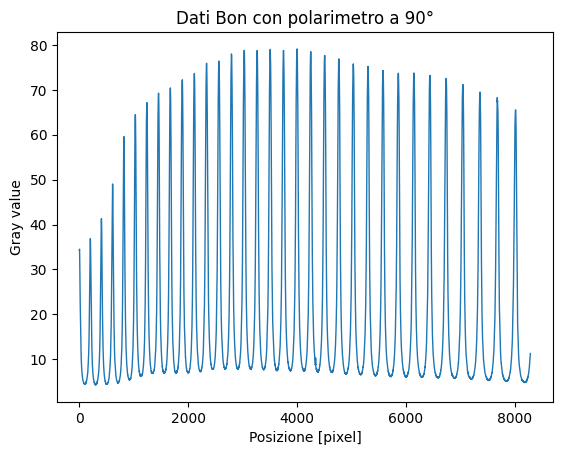

In [20]:
# Analisi spettro lamina inserita
dataLamBr0 = pd.read_csv('CSV/Marco_Polo_a90.csv') #Lamina in B non ruotato
x2 = dataLamBr0['Distance_(pixels)']
y2 = dataLamBr0['Gray_Value']
# Genero il canvas dei grafici
fig, ax = plt.subplots()
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")

plt.title("Dati Bon con polarimetro a 90°")

plt.plot(x2,y2, lw = 1,label='Data')
plt.show()

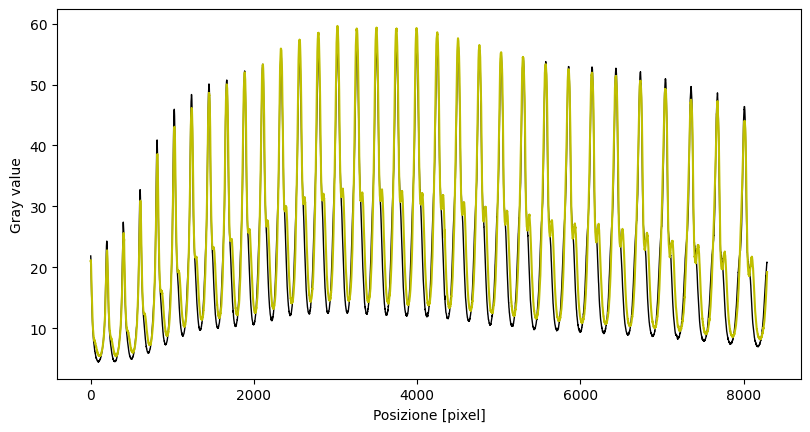

In [26]:
fig, ax = plt.subplots(figsize = (9.6,4.8))
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")

plt.plot(x,y, lw = 1,c = 'k', label='Misure senza polarimetro', alpha = 1)
plt.plot(x,y1/1.5+y2/2, c='y', label ='Somma misure con il polarimetro')

plt.title("Confronto misure con polarimetro")

# plt.plot(x1,y1/1.5, c = 'b',lw = 1,label='Data')
# plt.plot(x2,y2/2, c = 'r' ,lw = 1,label='Data')
plt.show()

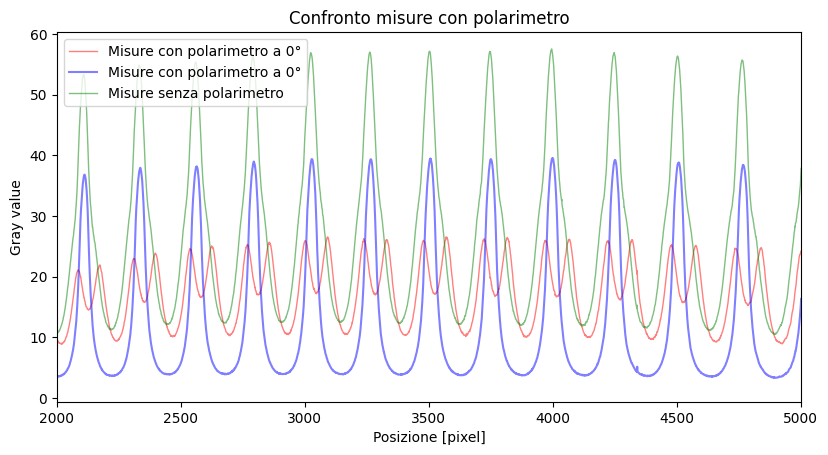

In [34]:
fig, ax = plt.subplots(figsize = (9.6,4.8))
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")

plt.plot(x1,y1/1.5, lw = 1,c = 'r', label='Misure con polarimetro a 0°', alpha = 0.5)
plt.plot(x2,y2/2, c='b', label ='Misure con polarimetro a 0°', alpha = 0.5)
plt.plot(x,y, lw = 1,c = 'g', label='Misure senza polarimetro', alpha = 0.5)

plt.legend()

ax.set_xlim(2000,5000)

plt.title("Confronto misure con polarimetro")

# plt.plot(x1,y1/1.5, c = 'b',lw = 1,label='Data')
# plt.plot(x2,y2/2, c = 'r' ,lw = 1,label='Data')
plt.show()

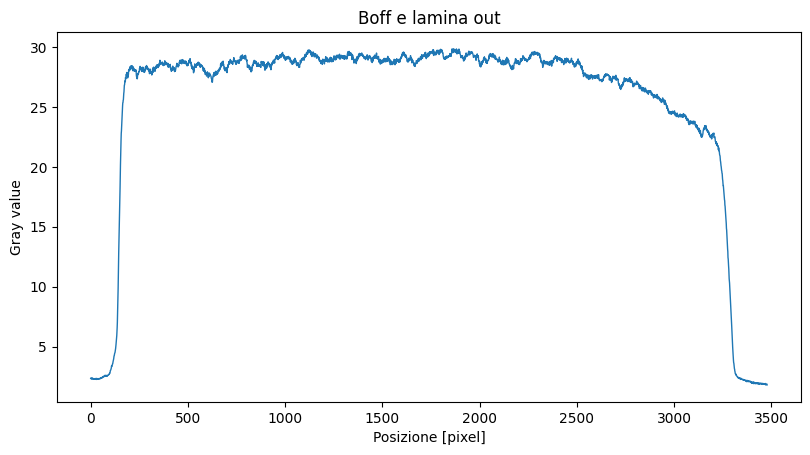

In [56]:
# Analisi spettro lamina inserita
datanLam = pd.read_csv('CSV/Grezza.csv') #Grezzo
x = datanLam['Distance_(pixels)']
y = datanLam['Gray_Value']
# Genero il canvas dei grafici
fig, ax = plt.subplots(figsize = (9.6,4.8))
ax.set_xlabel("Posizione [pixel]")
ax.set_ylabel("Gray value")

plt.title("Boff e lamina out")

plt.plot(x,y, lw = 1,label='Data')
plt.show()